# On-Orbit Power System Analysis and Anomaly Detection in CubeSats
This notebook analyzes the telemetry data from 4 different 1U CubeSats (TSURU, NEPALISAT, RAAVANA, and UGUISU). The data contains telemetry for the Electrical Power System (EPS), including Voltage (mV), Current (mA), and Temperature (°C) for 5 solar panels (+X, -X, +Y, -Z, +Z) and the battery.

We will cover:
1. **Data Loading & Preprocessing:** Dynamically loading and cleaning datasets.
2. **Power Cycle & Thermal Analysis:** Examining battery charge/discharge cycles and panel temperatures.
3. **Anomaly Detection:** Identifying the exact moment of permanent solar panel failures.

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os



## Section 1: Data Loading & Preprocessing
In this section, we build a robust function to dynamically load all `.csv` files for a given satellite. 
We use `glob` to find the files, `pd.concat` to merge them, and apply several cleaning steps:
- Stripping whitespace from column names.
- Handling missing values using interpolation.
- Creating a continuous relative time index.

In [191]:

def load_and_clean_satellite_data(satellite_name, base_path='./'):
    """
    Loads all Excel files for a given satellite and cleans the data.
    
    The folder containing .xlsx files 
        
    Returns:
        pd.DataFrame
    """
    # 1. Find Excel files
    file_pattern = os.path.join(base_path, f"{satellite_name}*.xlsx")
    file_list = glob.glob(file_pattern)
    
    if not file_list:
        print(f"No Excel files found for {satellite_name}.")
        return pd.DataFrame()
    
    # 2. Load and concatenate
    df = pd.concat([pd.read_excel(f) for f in file_list], ignore_index=True)
    
    # 3. Clean column names
    df.columns = df.columns.str.strip()
    
    # 4. Interpolate numeric columns
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].interpolate().bfill().ffill()
    
    # 5. Sort time if available
    if 'Time Stamp' in df.columns:
        df = df.sort_values('Time Stamp').reset_index(drop=True)
        df['Relative Time (samples)'] = df.index
    
    return df
"""
interpolate is a method used to fill missing values (NaN) by estimating them from nearby data points.

Instead of leaving gaps or blindly copying values, it reconstructs missing values based on a trend.

select_dtypes() is used to filter columns by their data type in a DataFrame.
"""


'\ninterpolate is a method used to fill missing values (NaN) by estimating them from nearby data points.\n\nInstead of leaving gaps or blindly copying values, it reconstructs missing values based on a trend.\n\nselect_dtypes() is used to filter columns by their data type in a DataFrame.\n'

## Section 2: Power Cycle & Thermal Analysis
Here we analyze the battery's charge and discharge cycles and the thermal behavior of the satellite.
- **Power Cycles:** We use `.rolling()` to smooth sensor noise and conditional masking to distinguish between eclipse (discharging) and sunlight (charging).
How rolling() works:
At each position:
Take last N values (window size)
Apply function (mean, sum, etc.)
Move one step forward
Repeat
example :
Raw signal:
10, 50, 12, 48, 11
Rolling mean (window=3):
NaN, NaN, 24, 36.7, 23.7
Without rolling:
data is noisy
spikes dominate
With rolling mean:
noise is reduced
trends become visible

- **Thermal Analysis:** We use `.describe()` and plot the hottest panel against the battery temperature to visualize thermal insulation.
.describe() output :
- | metric | meaning                   |
| ------ | ------------------------- |
| count  | number of non-null values |
| mean   | average                   |
| std    | standard deviation        |
| min    | minimum value             |
| 25%    | first quartile            |
| 50%    | median                    |
| 75%    | third quartile            |
| max    | maximum value             |


In [192]:

def plot_satellite_power_cycles(satellite_name, window_size=10):
    """
    Plots battery voltage cycles (smoothed) and highlights eclipse/sunlight regions
    based on battery current sign.

    Works for multiple satellites with similar telemetry structure.
    """

    # Load data
    df = load_and_clean_satellite_data(satellite_name)

    if df.empty:
        print(f"No data for {satellite_name}")
        return

    # ---- Column detection ----
    vbat_col = [c for c in df.columns if 'Vbat' in c and '(V)' in c]
    ibatt_col = [c for c in df.columns if 'Ibatt' in c and '(mA)' in c]

    if not vbat_col or not ibatt_col:
        print(f"Missing required columns for {satellite_name}")
        return

    vbat_col = vbat_col[0]
    ibatt_col = ibatt_col[0]

    # ---- Smoothing ----
    df['Vbat_smoothed'] = df[vbat_col].rolling(window=window_size, min_periods=1).mean()
    df['Ibatt_smoothed'] = df[ibatt_col].rolling(window=window_size, min_periods=1).mean()

    # ---- Phase detection (ASSUMPTION: check per satellite if needed) ----
    eclipse_mask = df['Ibatt_smoothed'] < 0
    sunlight_mask = df['Ibatt_smoothed'] >= 0

    # ---- Plot ----
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(df.index, df['Vbat_smoothed'],
             color='black', linewidth=1,
             label='Smoothed Battery Voltage')

    ax1.fill_between(
        df.index, 0, 1,
        where=eclipse_mask,
        transform=ax1.get_xaxis_transform(),
        color='gray', alpha=0.3,
        label='Eclipse (Discharging)'
    )

    ax1.fill_between(
        df.index, 0, 1,
        where=sunlight_mask,
        transform=ax1.get_xaxis_transform(),
        color='yellow', alpha=0.3,
        label='Sunlight (Charging)'
    )

    ax1.set_xlabel('Relative Time (samples)')
    ax1.set_ylabel('Battery Voltage (V)')
    ax1.set_title(f'{satellite_name} Battery Power Cycles')
    ax1.legend(loc='upper right')

    plt.tight_layout()
    plt.show()




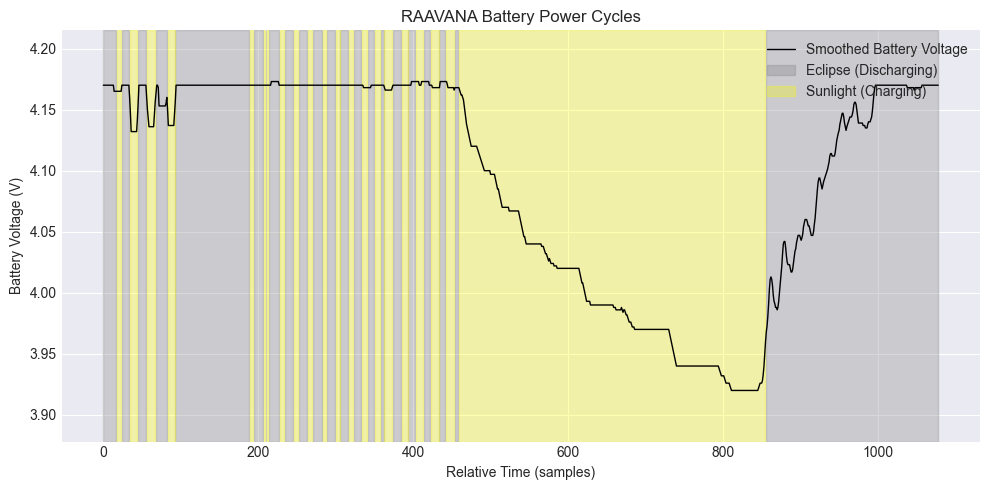

In [193]:
plot_satellite_power_cycles('RAAVANA')


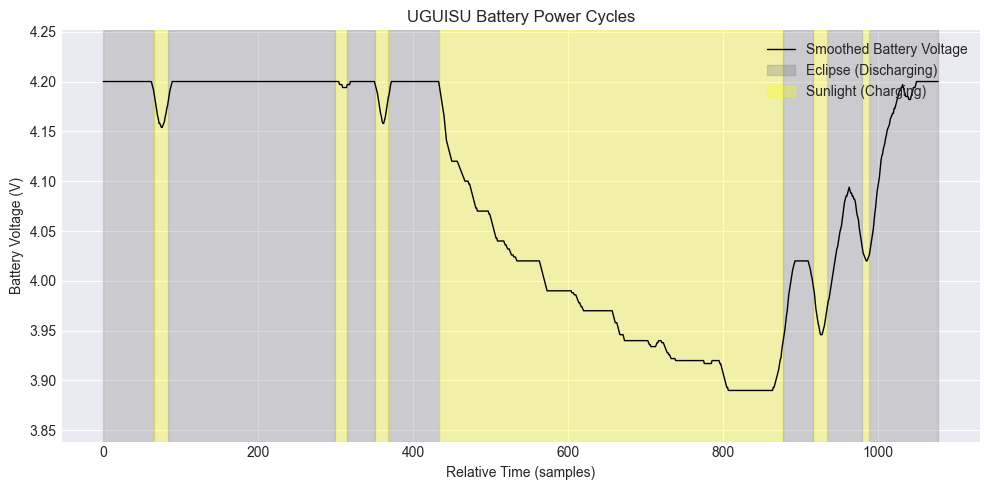

In [194]:
plot_satellite_power_cycles('UGUISU')

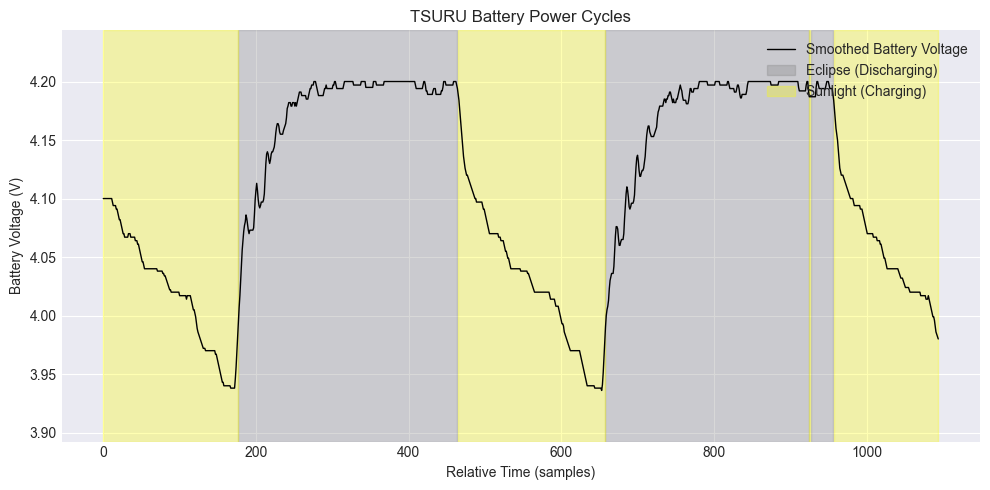

In [195]:
plot_satellite_power_cycles('TSURU')

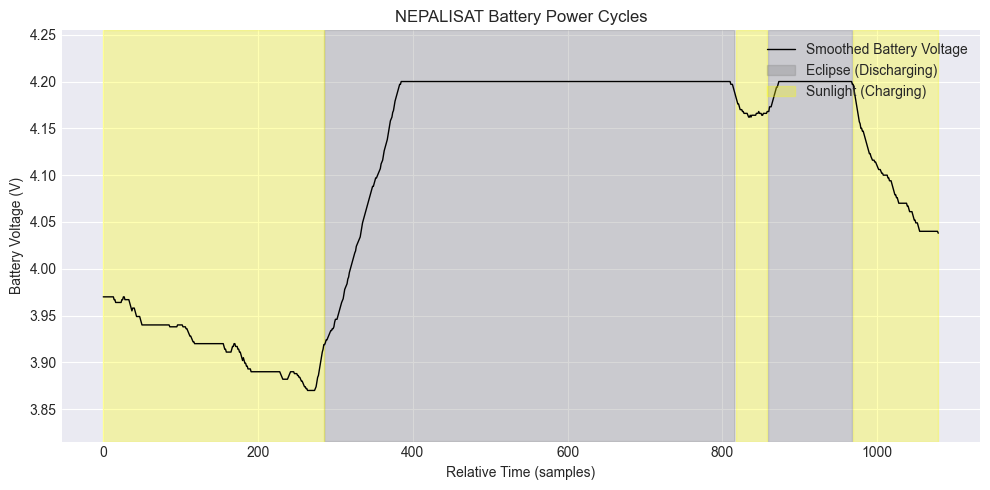

In [196]:
plot_satellite_power_cycles('NEPALISAT')

In [197]:
def thermal_analysis(df, satellite_name='Satellite'):
    if df.empty:
        return

    # ── Find battery temperature column ─────────────────────────────────────
    # Match calibrated Tbatt column: must contain 'Tbatt' and a degree symbol or 'C'
    # Explicitly exclude raw columns (which contain 'raw')
    tbatt_candidates = [
        c for c in df.columns
        if 'Tbatt' in c and 'raw' not in c.lower()
    ]
    if not tbatt_candidates:
        print(f"[{satellite_name}] Could not find battery temperature column.")
        return
    tbatt_col = tbatt_candidates[0]

    # ── Find panel temperature columns ───────────────────────────────────────
    # Match any calibrated temp column that isn't the battery
    panel_temp_cols = [
        c for c in df.columns
        if ('(°C)' in c or '(℃)' in c or '(C)' in c)
        and 'raw' not in c.lower()
        and 'Tbatt' not in c
    ]
    if not panel_temp_cols:
        print(f"[{satellite_name}] Could not find panel temperature columns.")
        return

    print(f"Battery temp column : {tbatt_col}")
    print(f"Panel temp columns  : {panel_temp_cols}")

    # ── Summary statistics ───────────────────────────────────────────────────
    print("\nSummary Statistics for Temperatures:")
    display(df[panel_temp_cols + [tbatt_col]].describe())

    # ── Compute hottest panel at each timestamp ──────────────────────────────
    df['Hottest_Panel_Temp'] = df[panel_temp_cols].max(axis=1)

    # ── Plot ─────────────────────────────────────────────────────────────────
    plt.figure(figsize=(14, 5))
    plt.plot(df.index, df['Hottest_Panel_Temp'],
             color='red', alpha=0.7, linestyle='--', label='Hottest Panel (External)')
    plt.plot(df.index, df[tbatt_col],
             color='blue', linewidth=2, label='Battery Temp (Internal)')

    plt.xlabel('Relative Time (samples)')
    plt.ylabel('Temperature (°C)')
    plt.title(f'{satellite_name} — Thermal Insulation: External Extremes vs Internal Battery')
    plt.legend()
    plt.tight_layout()
    plt.show()  # ← plain function call, no markdown link



Battery temp column : Tbatt (℃)
Panel temp columns  : ['Tpy (°C)', 'Tpx (°C)', 'Tmz (°C)', 'Tmx (°C)', 'Tpz (°C)']

Summary Statistics for Temperatures:


,Tpy (°C),Tpx (°C),Tmz (°C),Tmx (°C),Tpz (°C),Tbatt (℃)
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,-2.226676,-2.177023,-7.933836,-5.875260,2.004822,8.250055
std,13.102218,12.957185,11.734688,10.083313,18.253718,1.513311
min,-24.440000,-25.770000,-23.670000,-20.560000,-27.330000,5.670000
25%,-13.900000,-14.065000,-18.175000,-14.625000,-13.955000,6.820000
50%,-2.250000,-2.140000,-9.240000,-6.690000,1.640000,8.730000
75%,10.570000,10.180000,-1.970000,-0.140000,14.125000,9.500000
max,21.390000,19.280000,20.390000,16.950000,42.700000,10.650000


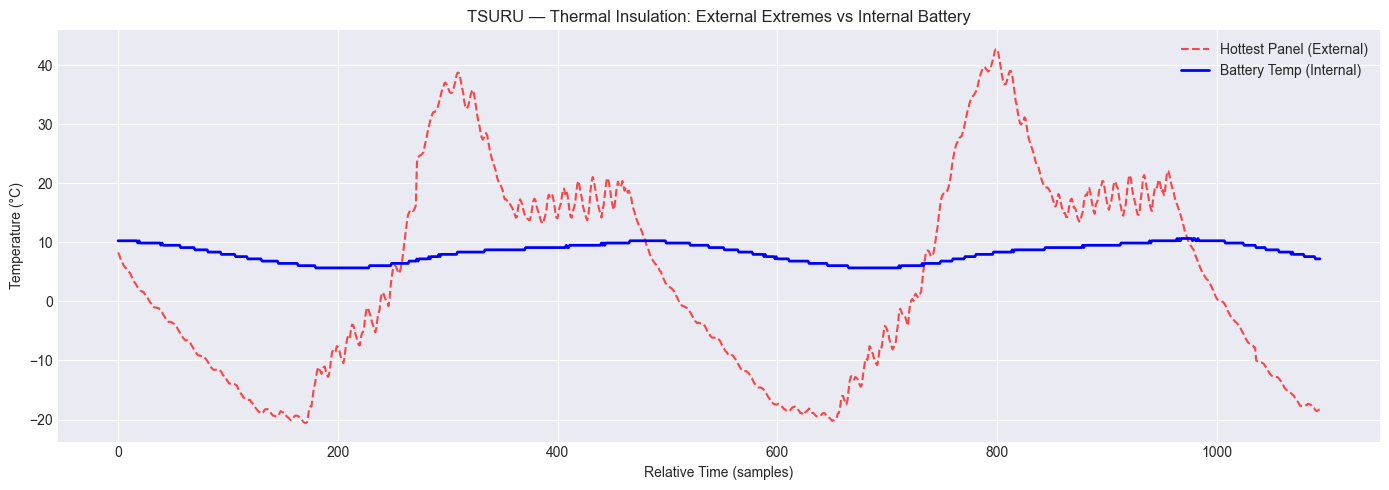

Battery temp column : Tbatt (℃)
Panel temp columns  : ['Tpy (°C)', 'Tpx (°C)', 'Tmz (°C)', 'Tmx (°C)', 'Tpz (°C)']

Summary Statistics for Temperatures:


,Tpy (°C),Tpx (°C),Tmz (°C),Tmx (°C),Tpz (°C),Tbatt (℃)
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,-2.923046,-5.557120,-2.714204,-1.037204,12.302102,6.650074
std,15.801308,15.551503,16.866398,13.168257,29.837122,1.442053
min,-28.330000,-25.550000,-32.320000,-24.220000,-17.780000,4.520000
25%,-16.560000,-23.110000,-18.670000,-8.800000,-12.350000,5.280000
50%,-2.360000,-2.360000,3.465000,-3.360000,-0.690000,6.820000
75%,5.767500,9.400000,5.740000,4.547500,41.030000,7.960000
max,31.380000,24.160000,32.820000,34.370000,66.440000,8.730000


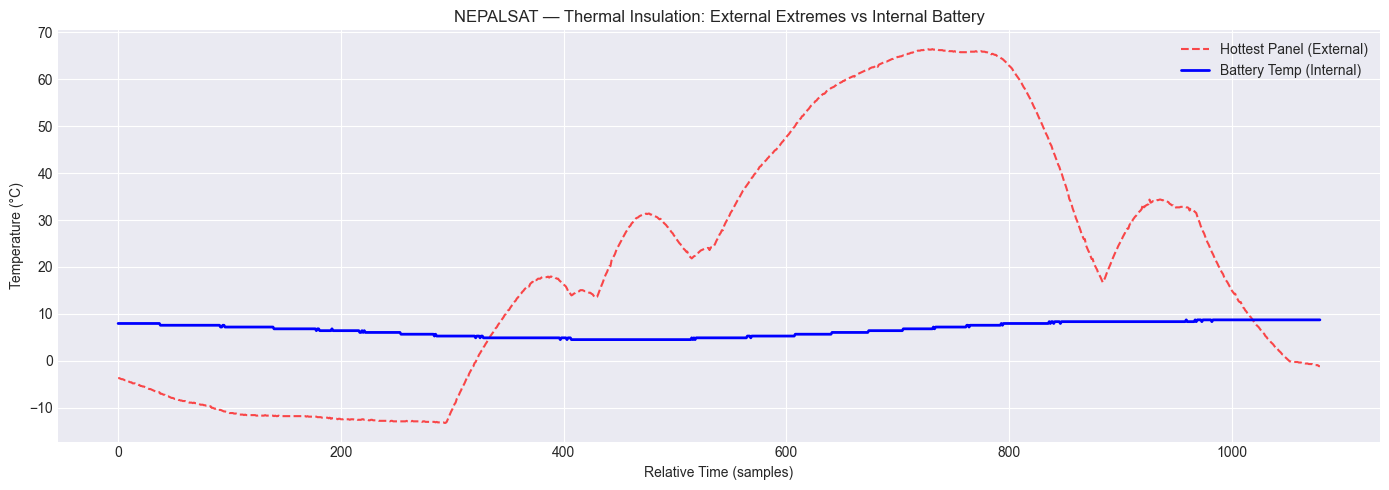

In [200]:
df_tsuru= load_and_clean_satellite_data("TSURU")
thermal_analysis(df_tsuru,'TSURU')
df_nepalisat= load_and_clean_satellite_data("NEPALISAT")
thermal_analysis(df_nepalisat,'NEPALSAT')

## Section 3: Anomaly Detection (Finding the Failed Panel)
UGUISU suffered a permanent failure in one of its solar panels. 
Using pandas, we will calculate rolling statistics to detect when a specific panel's current drops to almost 0 mA and never recovers.

[UGUISU] ANOMALY DETECTED
  Panel : Ipy (mA)
  Type  : never generates significant current (max=42.0 mA, high_frac=0.0%, unique_vals=4)
  Onset : sample index 399


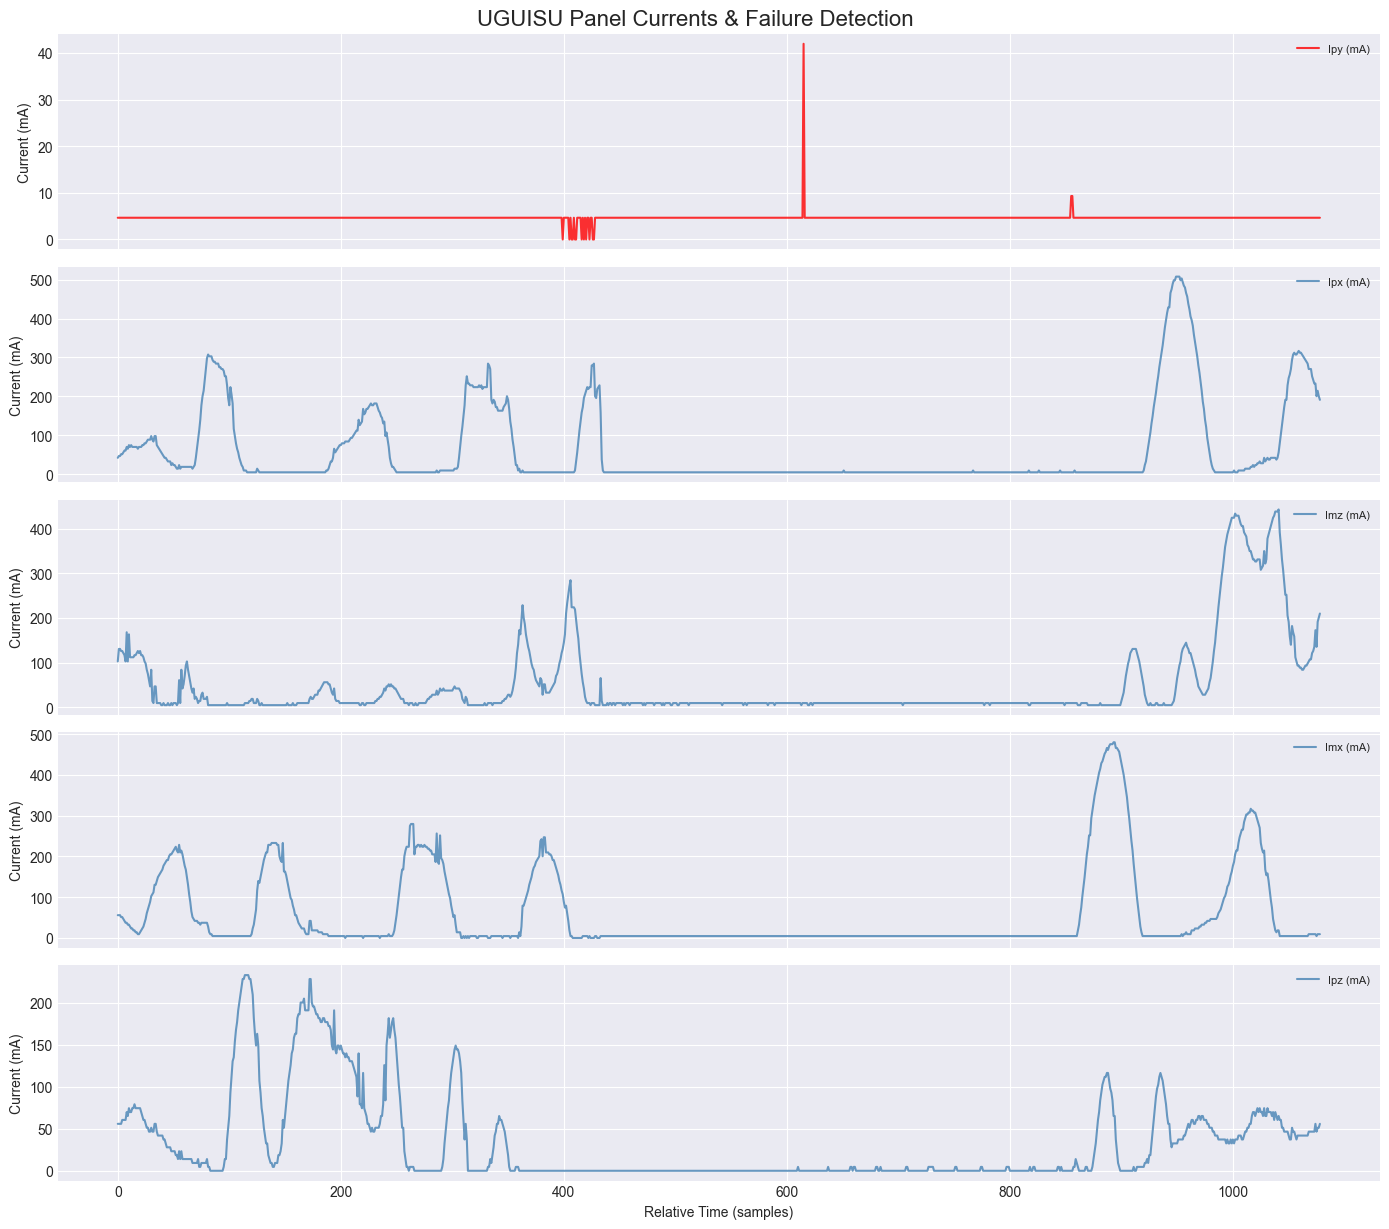

[RAAVANA] ANOMALY DETECTED
  Panel : Ipy (mA)
  Type  : never generates significant current (max=46.6 mA, high_frac=0.0%, unique_vals=5)
  Onset : sample index 23


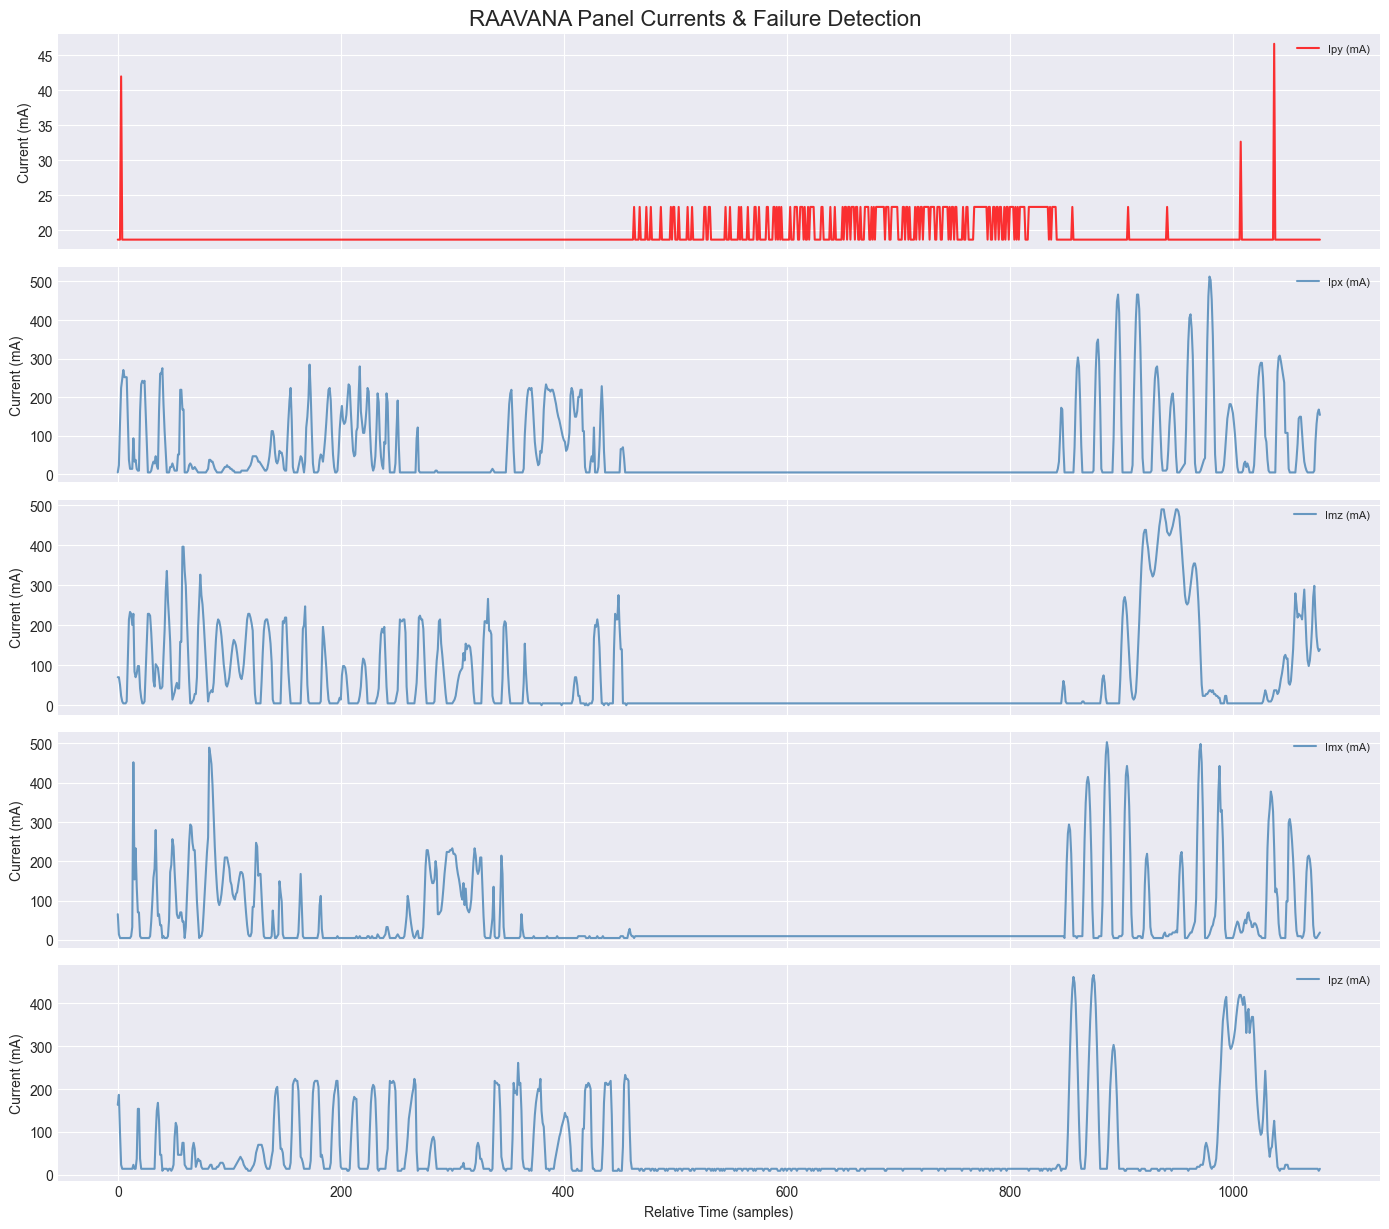

[NEPALISAT] No permanent panel failure detected. ✓
[TSURU] No permanent panel failure detected. ✓


In [199]:
# Opposite panel map — used to find failure onset more precisely
OPPOSITE_PANEL = {
    'Ipx (mA)': 'Imx (mA)', 'Imx (mA)': 'Ipx (mA)',
    'Ipz (mA)': 'Imz (mA)', 'Imz (mA)': 'Ipz (mA)',
    'Ipy (mA)': None,
}

def detect_panel_failure(df, satellite_name):
    if df.empty:
        return

    current_cols = [c for c in df.columns
                    if 'I' in c and '(mA)' in c and 'batt' not in c.lower()]
    if not current_cols:
        print(f"[{satellite_name}] No panel current columns found.")
        return

    # ── Thresholds ──────────────────────────────────────────────────────────────
    # A healthy panel must reach this current level in at least some samples.
    # Failed panels never exceed their sensor noise floor (~46 mA max observed).
    # All healthy panels across all 4 sats reach 233+ mA.
    HIGH_CURRENT_THRESHOLD = 100.0   # mA
    HIGH_FRAC_MIN          = 0.05    # at least 5% of samples must exceed threshold
    UNIQUE_VAL_CUTOFF      = 10      # fewer unique values → stuck at noise floor
    # For onset detection (Strategy 1 - UGUISU style)
    SUNLIGHT_THRESHOLD     = 10.0    # mA — any other panel above this = sunlight
    ZERO_THRESHOLD         = 1.0     # mA — below this = near-zero

    failure_detected = False
    failed_panel     = None
    failure_index    = None
    failure_type     = None

    for col in current_cols:
        panel    = df[col]
        high_frac = (panel > HIGH_CURRENT_THRESHOLD).mean()
        n_unique  = panel.nunique()

        # ── Primary check: did this panel EVER generate meaningful power? ────────
        # A shaded-but-healthy panel still generates high current when it faces the sun.
        # A failed panel never breaks out of the noise floor.
        panel_is_failed = (high_frac < HIGH_FRAC_MIN) or (n_unique < UNIQUE_VAL_CUTOFF)

        if not panel_is_failed:
            continue

        failed_panel     = col
        failure_type     = (f"never generates significant current "
                            f"(max={panel.max():.1f} mA, "
                            f"high_frac={high_frac:.1%}, "
                            f"unique_vals={n_unique})")

        # ── Find failure onset ───────────────────────────────────────────────────
        # Use the opposite panel as a sunlight proxy:
        # when the opposite face IS generating current, this face should too.
        opp = OPPOSITE_PANEL.get(col)
        other_cols = [c for c in current_cols if c != col]

        if opp and opp in df.columns:
            # Opposite panel lit = this panel's face was definitely shaded — not useful.
            # Use the remaining non-opposite panels as the sunlight proxy instead.
            proxy_cols = [c for c in other_cols if c != opp]
        else:
            proxy_cols = other_cols

        if proxy_cols:
            proxy_active = df[proxy_cols].max(axis=1) > SUNLIGHT_THRESHOLD
        else:
            proxy_active = pd.Series(True, index=df.index)

        # Find where this panel diverges: proxy says sunlight, panel stays near-zero
        diverging = (panel < ZERO_THRESHOLD) & proxy_active
        if diverging.any():
            failure_index = df.index[diverging].min()
        else:
            # Panel is stuck at noise floor (not zero, like RAAVANA Ipy at 18.64 mA)
            # Onset = first sample where rolling std is essentially flat
            rolling_std = panel.rolling(window=20, min_periods=5).std()
            flat = rolling_std < 0.5
            failure_index = df.index[flat].min() if flat.any() else df.index[0]

        failure_detected = True
        break  # stop at first failed panel found

    if failure_detected:
        print(f"[{satellite_name}] ANOMALY DETECTED")
        print(f"  Panel : {failed_panel}")
        print(f"  Type  : {failure_type}")
        print(f"  Onset : sample index {failure_index}")

        fig, axes = plt.subplots(len(current_cols), 1,
                                 figsize=(14, 2.5 * len(current_cols)), sharex=True)
        fig.suptitle(f'{satellite_name} Panel Currents & Failure Detection', fontsize=16)

        for i, col in enumerate(current_cols):
            color = 'red' if col == failed_panel else 'steelblue'
            axes[i].plot(df.index, df[col], alpha=0.8, color=color, label=col)
            axes[i].set_ylabel('Current (mA)')
            axes[i].legend(loc='upper right', fontsize=8)

        axes[-1].set_xlabel('Relative Time (samples)')
        plt.tight_layout()
        plt.show()
    else:
        print(f"[{satellite_name}] No permanent panel failure detected. ✓")
# Load data and run detection

df_uguisu = load_and_clean_satellite_data('UGUISU')
detect_panel_failure(df_uguisu, 'UGUISU')


df_raavana = load_and_clean_satellite_data('RAAVANA')
detect_panel_failure(df_raavana, 'RAAVANA')


detect_panel_failure(df_nepalisat, 'NEPALISAT')
detect_panel_failure(df_tsuru, 'TSURU')

